
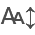

In [1]:
import os
import sys
import numpy as np
import scipy as sp
from importlib import reload
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import json
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)


sys.path.insert(0, '../scripts')

from Block_analysis import *
import small_utilities
reload( small_utilities)
from small_utilities import *

import seaborn as sns

import mdtraj as md


# Overview

This notebook will be used for analysis of the 10 replica REST2 trajectory of apo $\alpha$-synuclien. `small_utilities` and `Block_analysis` files contain usefull functions which we use for analysis and plotting. These files can be found in the `scripts` folder.

# Preparation to load the data

In [2]:
sequence=  ['ASP121', 'ASN122', 'GLU123', 'ALA124', 'TYR125', 'GLU126', 'MET127', 'PRO128', 'SER129', 'GLU130', 'GLU131', 'GLY132', 'TYR133', 'GLN134', 'ASP135',
'TYR136', 'GLU137', 'PRO138', 'GLU139', 'ALA140']

w_dir= '/data/ssREST3/'

data_list_apo= [f"{w_dir}//Apo/REST2-1/", # 0 - 10 reps
                f"{w_dir}//Apo/REST2-2/", # 1 - 20 reps
                f"{w_dir}//Apo/REST3-1_1/", # 2 - 8 reps
                f"{w_dir}//Apo/REST3-2/"] # 3 - 16 reps


legend_title= ['REST2 (10)', 'REST2 (20)', 'ssREST3 (08)', 'ssREST3 (16)']

color, marker = markers_colors()

temperature={ 0 : compute_temperatures((300, 450), 10),
              1 : compute_temperatures((300, 600), 20),
              2 : compute_temperatures((300, 450), 8),
              3 : compute_temperatures((300, 450), 16)}

ticks_pnum, ticks_pname = sequence_ticks_1(sequence)

nrep=[10, 20, 8, 16]

In [3]:
files = os.listdir(data_list_apo[0])

# Filter out JSON files
json_files = np.array([file for file in files if file.endswith('.json')])

print(json_files)

['sheet_contant.json' 'alphabeta_ppII.json' 'pp.json' 'p_contact_map.json'
 'alphabeta_betasheet.json' 'rg.json' 'helix_contant.json' 'sa.json'
 'alphabeta_alpharight.json' 'bend_angle.json']


# Loading the relevent data

In [4]:
files = ['rg.json', 'helix_contant.json', 'sheet_contant.json', 'p_contact_map.json', 'bend_angle.json', 'replica_temp.xvg','replica_index.xvg',]

rg=load_json(f'{data_list_apo[0]}/{files[0]}')
helix=load_json(f'{data_list_apo[0]}/{files[1]}')
sheet=load_json(f'{data_list_apo[0]}/{files[2]}')
p_cm=load_json(f'{data_list_apo[0]}/{files[3]}')
ba=load_json(f'{data_list_apo[0]}/{files[4]}')

xvg_temp=np.loadtxt(f'{data_list_apo[0]}/{files[5]}', comments=['#','@'])
xvg_index=np.loadtxt(f'{data_list_apo[0]}/{files[6]}', comments=['#','@'])


# Plot of Radius of Gyration for different replica temperatures

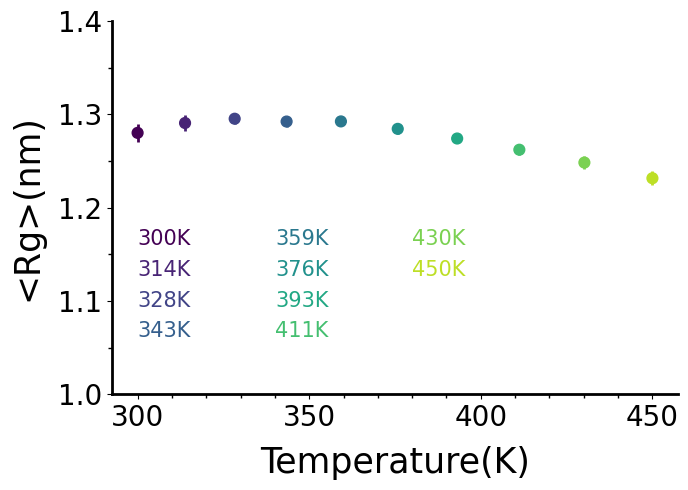

In [8]:
fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(temperature[0],[get_blockerror_pyblock_nanskip(np.array(rg[f'rep:{i}']))[0] for i in range(nrep[0])], s=60, c=[plt.cm.viridis(i/nrep[0]) for i in range(nrep[0])])
ax.errorbar(temperature[0],[get_blockerror_pyblock_nanskip(np.array(rg[f'rep:{i}']))[0] for i in range(nrep[0])], elinewidth=2, 
            yerr=[get_blockerror_pyblock_nanskip(np.array(rg[f'rep:{i}']))[1] for i in range(nrep[0])], ecolor=[plt.cm.viridis(i/nrep[0]) for i in range(nrep[0])], ls='none')

ax.tick_params(labelsize=20)
ax.set_yticks(np.arange(1.0,1.5,0.1),[f"{i:2.1f}" for i in np.arange(1.0,1.5,0.1)])
ax.set_xticks(np.arange(300,500,50), np.arange(300,500,50))
ax.set_xlabel("Temperature(K)", labelpad=10, size=25)
ax.set_ylabel("<Rg>(nm)", labelpad=10, size=25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(50/5))
ax.tick_params(axis='x', which='minor', length=3, width=1, color='k', direction='out')
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(0.1/2))
ax.tick_params(axis='y', which='minor', length=3, width=1, color='k', direction='out')

y = 1.16
x = 300
for i in range(len(temperature[0])):
        
    ax.text(x, y, f"{round(temperature[0][i])}K", size=15, color=plt.cm.viridis(i/nrep[0]))
    y=y-0.02
    if i % 4 == 3:
        x += 40
        y = 1.16
    else:
        y -= 0.013

plt.tight_layout()



From Rg vs Replica temperature plot for 10 replicas we can clearly observe that at higher temperatures there is a collapse of protein in absence of small molecule.

We are preparing the time series for the trajectory in the below code block, which will be used for further plotting and analysis.

In [9]:
# Inputs for compute_time are a time series data and time-step of the simulation

time = compute_time(rg['rep:0'], 80)

time

array([0.00000e+00, 8.00000e-05, 1.60000e-04, ..., 1.99984e+00,
       1.99992e+00, 2.00000e+00])

Here we are checking the code for aggregate time analysis for the observables. Here we use the `time` series we computed above. `magic_num` is used to break the time series or time series data at the required time break. We will check if that break is correct or not.

In [10]:
magic_num=125
time_agg_dict, time_agg, _ = compute_time_batches(80,
                                                  len(rg['rep:0']),
                                                  magic_num,
                                                  check=True)

Index: 10; # of frames: 1251, Time: 0.1 µs
Index: 20; # of frames: 2501, Time: 0.2 µs
Index: 30; # of frames: 3751, Time: 0.3 µs
Index: 40; # of frames: 5001, Time: 0.4 µs
Index: 50; # of frames: 6251, Time: 0.5 µs
Index: 60; # of frames: 7501, Time: 0.6 µs
Index: 70; # of frames: 8751, Time: 0.7 µs
Index: 80; # of frames: 10001, Time: 0.8 µs
Index: 90; # of frames: 11251, Time: 0.9 µs
Index: 100; # of frames: 12501, Time: 1.0 µs
Index: 110; # of frames: 13751, Time: 1.1 µs
Index: 120; # of frames: 15001, Time: 1.2 µs
Index: 130; # of frames: 16251, Time: 1.3 µs
Index: 140; # of frames: 17501, Time: 1.4 µs
Index: 150; # of frames: 18751, Time: 1.5 µs
Index: 160; # of frames: 20001, Time: 1.6 µs
Index: 170; # of frames: 21251, Time: 1.7 µs
Index: 180; # of frames: 22501, Time: 1.8 µs
Index: 190; # of frames: 23751, Time: 1.9 µs
Index: 200; # of frames: 25001, Time: 2.0 µs


# Plot of Free energy of Radius of Gyration for different aggegate times

By populating the `splits` list with required indices we can plot the respective free energies.

/data/ssREST3/Apo/../scripts/Block_analysis.py:86: RuntimeWarning: invalid value encountered in divide
  ferr = -(0.001987*T)*(error / average)
/data/ssREST3/Apo/../scripts/Block_analysis.py:86: RuntimeWarning: invalid value encountered in divide
  ferr = -(0.001987*T)*(error / average)
/data/ssREST3/Apo/../scripts/Block_analysis.py:86: RuntimeWarning: invalid value encountered in divide
  ferr = -(0.001987*T)*(error / average)
/data/ssREST3/Apo/../scripts/Block_analysis.py:86: RuntimeWarning: invalid value encountered in divide
  ferr = -(0.001987*T)*(error / average)


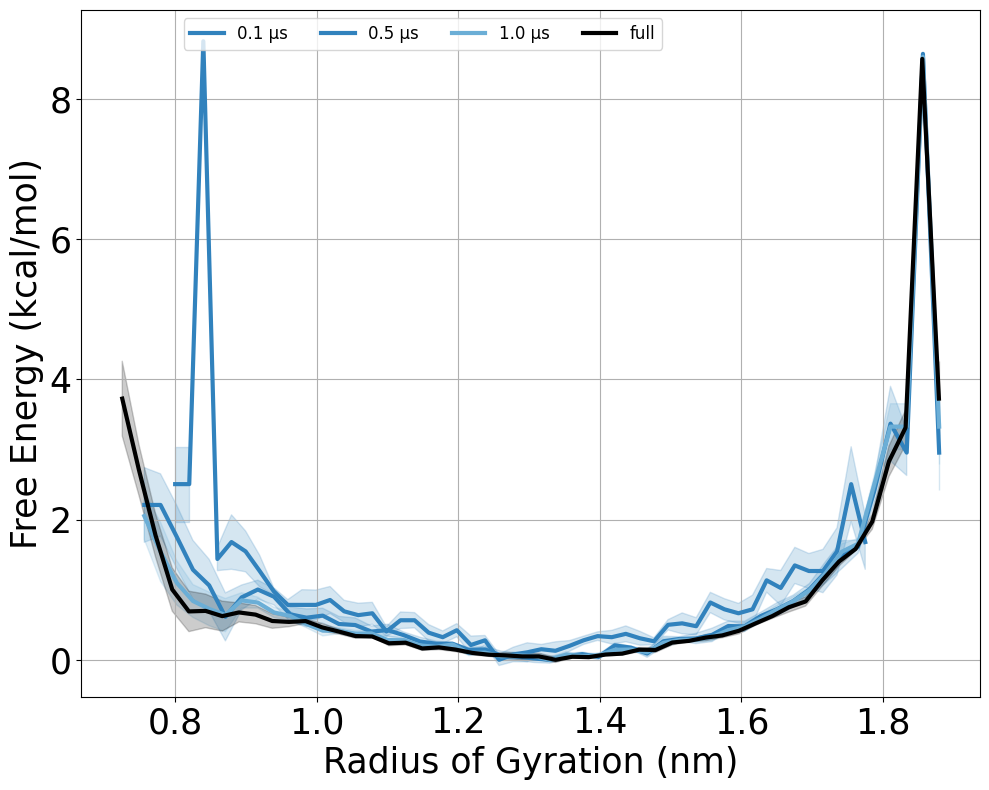

In [12]:
splits=[10, 50, 100]
magic_num=125

plt.figure(figsize=(10,8))

for i in splits :
        
    dG1, bin_centers, ferr = free_energy_1D_blockerror(rg['rep:0'][:int(magic_num*i)+1], T=300, x0=min(rg['rep:0'][:int(magic_num*i)+1]), xmax=max(rg['rep:0'][:int(magic_num*i)+1]), bins=50, blocks=5, weights=None)
    sns.lineplot(x=bin_centers, y=dG1, color=plt.cm.tab20c(int(i/100)), linewidth=3,label=f'{i/100} \u03bcs', linestyle='-')
    plt.fill_between(bin_centers, dG1-ferr, dG1+ferr, color=plt.cm.tab20c(int(i/100)), alpha=0.2)

dG1, bin_centers, ferr = free_energy_1D_blockerror(rg['rep:0'], T=300, x0=min(rg['rep:0']), xmax=max(rg['rep:0']), bins=50, blocks=5, weights=None)
sns.lineplot(x=bin_centers, y=dG1, color='k', linewidth=3,label='full', linestyle='-')
plt.fill_between(bin_centers, dG1-ferr, dG1+ferr, color='k', alpha=0.2)

# plt.ylim(-0.2, 6)
# plt.xlim(0.5, 2.25)
plt.xlabel('Radius of Gyration (nm)', size=25)
plt.ylabel('Free Energy (kcal/mol)', size=25)
plt.legend(loc='upper center', fontsize=12, ncol=5, bbox_to_anchor=(0.38, 1.0))
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.title(f"Replica : {val}", size=20)
plt.tight_layout()
plt.grid()
  

# Plot of aggregate Radius of Gyration

In [13]:
magic_num=125
time_split=[]
c=0

time_agg=[]
Rg_agg=[]

for i in range(10,510,10):
    c=len(time[:int(magic_num*i)+1])
    last=time[:int(magic_num*i)+1][-1]
    time_agg.append(last)
    
    if c in time_split : break

    time_split.append(c)
    Rg_agg.append(get_blockerror_pyblock_nanskip(np.array(rg['rep:0'][:int(magic_num*i)+1])))
    
    # print(i, c, last, kd_bf_data[0])
    # print(f"Time ==> {last} microsec; Total frames ==> {c}; Rg ==> {Rg_agg[int(i/10)-1][0]:0.4f}; Rg_err ==> {Rg_agg[int(i/10)-1][1]:0.4f}")

Rg_agg=np.array(Rg_agg)
time_agg=np.array(time_agg[:-1])


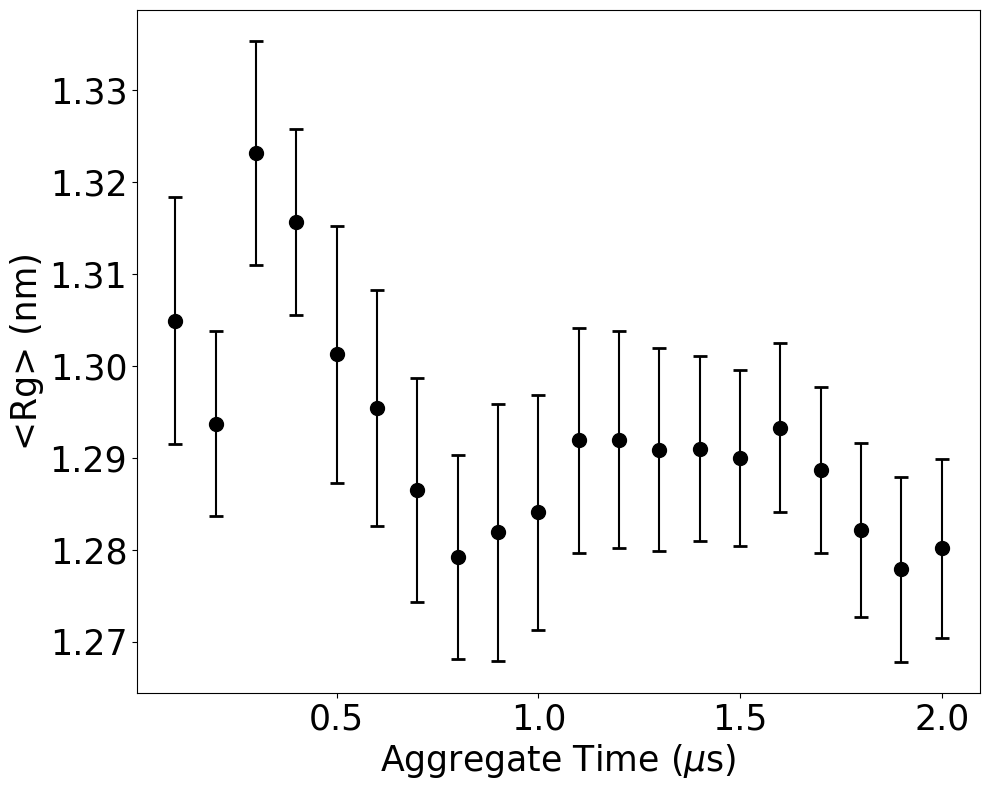

In [14]:
plt.figure(figsize=(10,8))

plt.errorbar(time_agg, Rg_agg.T[0], yerr=Rg_agg.T[1], fmt='o', color='black', markersize=10, capsize=5, capthick=2)

plt.tick_params(labelsize=25)
plt.xlabel(r'Aggregate Time ($\mu$s)', size=25)
plt.ylabel(r'<Rg> (nm)', size=25)
plt.tight_layout()

# Plot of protein bend angle w.r.t replica temperatures

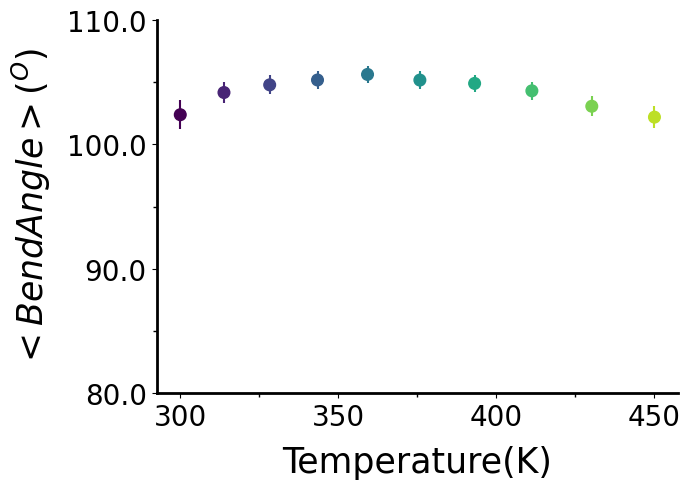

In [16]:
fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(temperature[0],[ba[f'rep:{i}'][0] for i in range(nrep[0])], s=70, c=[plt.cm.viridis(i/nrep[0]) for i in range(nrep[0])])
ax.errorbar(temperature[0],[ba[f'rep:{i}'][0] for i in range(nrep[0])], yerr=[ba[f'rep:{i}'][1] for i in range(nrep[0])], ecolor=[plt.cm.viridis(i/nrep[0]) for i in range(nrep[0])], ls='none')

ax.tick_params(labelsize=20)
ax.set_yticks(np.arange(80,120,10),[f"{i:2.1f}" for i in np.arange(80,120,10)])
ax.set_xticks(np.arange(300,500,50), np.arange(300,500,50))
ax.set_xlabel("Temperature(K)", labelpad=10, size=25)
ax.set_ylabel(r"$<Bend Angle>(^{O})$", labelpad=10, size=25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(50/2))
ax.tick_params(axis='x', which='minor', length=3, width=1, color='k', direction='out')
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(10/2))
ax.tick_params(axis='y', which='minor', length=3, width=1, color='k', direction='out')

plt.tight_layout()


We can observe similar behaviour of bend angle as Radius of Gyration which shows clear collapse of protein at higher temparatures.

# Plot of helical and $\beta$-sheet content

<Figure size 1500x500 with 0 Axes>

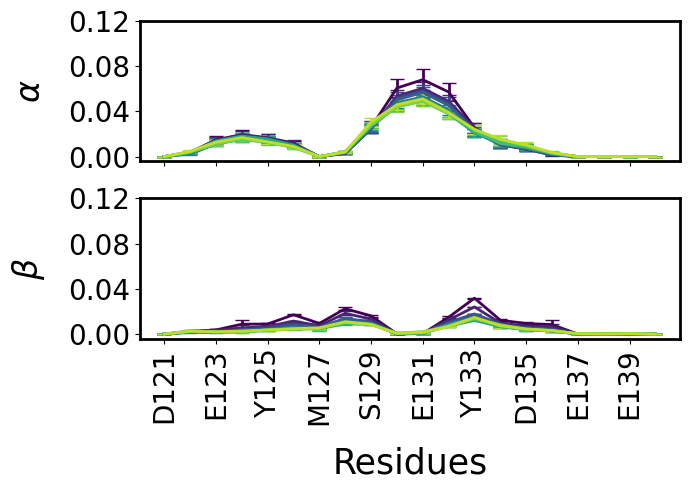

In [17]:
in_dict={int(i.split(':')[1]):helix[i] for i in helix.keys() if 'rep' in i}
in_dict_2={int(i.split(':')[1]):sheet[i] for i in sheet.keys() if 'rep' in i}

plt.figure(figsize=(15,5))

fig, axes = plt.subplots(2,1, figsize=(7,5), sharex=True, sharey=True)

for i in in_dict.keys():
        
    axes[0].errorbar(ticks_pnum, np.array(in_dict[i]).T[0], yerr=np.array(in_dict[i]).T[1], color=plt.cm.viridis(i/nrep[0]), lw=2, capsize=5)
    axes[1].errorbar(ticks_pnum, np.array(in_dict_2[i]).T[0], yerr=np.array(in_dict_2[i]).T[1], color=plt.cm.viridis(i/nrep[0]), lw=2, capsize=5)

axes[0].tick_params(labelsize=20)
axes[0].set_ylabel(r'$\alpha$', size=24,labelpad=15)

axes[1].tick_params(labelsize=20)
axes[1].set_xticks(range(0,20,2), ticks_pnum[::2],rotation=90)
axes[1].set_yticks(np.arange(0,0.14,0.04))
axes[1].set_xlabel('Residues', size=25, labelpad=15)
axes[1].set_ylabel(r'$\beta$', size=24,labelpad=15)

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        
# y=0.1
# x=0
# for i in range(len(temperature[1])):
        
#     axes[1].text(x, y, f"{round(temperature[1][i])}K", size=15, color=plt.cm.viridis(i/nrep[0]))
#     y=y-0.025
#     if i%2 : x = x+4 ; y=0.1

plt.tight_layout()



# Plot of inra-residue contact map

In [19]:
plot_args={'vmin': 0.0,
           'vmax': 0.5,
           'fig_size': (24,12),
        #    'cax_coor': [1, .095, .025, .874],
           'cmap': 'jet',
           'aspect' : 'auto',
           'rotation' : {'x' : 90, 'y' :0},
           'tick_size' : {'x' : 28, 'y' : 28, 'cax' :30},
           'label_size' : {'x' : 38, 'y' : 38, 'cax' :36},
           'title_size' :28,
           'dpi' : 210,
           'labels' : {'x' :"Residues", 'y':"Residues" },
           'nrows' : 2,
           'ncols' : 5,
           'xticks' : [" "  if i%3 else ticks_pnum[i] for i in range(len(ticks_pname)) ],
           'yticks' : [" "  if i%3 else ticks_pnum[i] for i in range(len(ticks_pname)) ],
           'tick_interval' : 1}

in_dict={int(i.split(':')[1]):p_cm[i] for i in p_cm.keys() if 'rep' in i}
plot_cm_all(in_dict, 'Contact Fraction', show_fig=True, title_dict=[f'{round(temperature[0][i])}K' for i in range(nrep[0])], offset=1, 
             plot_args_in=plot_args)

# Loading the *zeroth* replica trajectory to compute intra-residue and dual-residue contact maps w.r.t aggregate time

In [5]:
pdb = '/data/ssREST3/xtc/REST2/pbc_apo_ions.pdb'
xtc = '/data/ssREST3/xtc/REST2/apo_10/r/pbc_0.xtc'

traj = md.load(xtc, top=pdb)
traj = traj.atom_slice(traj.topology.select('resid 0 to 19'))
traj.center_coordinates()

<mdtraj.Trajectory with 25001 frames, 294 atoms, 20 residues, and unitcells at 0x7fc81fcef7d0>

## Computing and plotting intra-residue contact map w.r.t aggregate time

In [6]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

magic_num = 125
i_vals = np.arange(10, 510, 10)  # 10,20,...,500

# Build end-frame list once; cap to trajectory length
end_frames = (magic_num * i_vals + 1).astype(int)
max_frames = len(traj)  # or len(time) if you really need 'time'

end_frames = np.clip(end_frames, 1, max_frames)

# Keep only strictly increasing end frames (avoid duplicate work)
keep = np.concatenate(([True], np.diff(end_frames) > 0))
i_keep = i_vals[keep]
end_keep = end_frames[keep]

# time_agg matches the *kept* batches (equivalent to your time_agg[:-1])
time = compute_time(rg['rep:0'], 80)
time_agg = np.asarray([time[ef - 1] for ef in end_keep])

# Prepare jobs: dict keys as before: int(i/10)-1
jobs = [(int(i/10)-1, ef) for i, ef in zip(i_keep, end_keep)]

# Put traj into each worker once via an initializer to avoid pickling every call
_TRJ = None
def _init(traj_obj):
    global _TRJ
    _TRJ = traj_obj

def _worker(end_frame):
    return contact_map_protein_rw(_TRJ[:end_frame])

p_cm_agg = {}
nprocs = mp.cpu_count()  # or set a smaller number
with ProcessPoolExecutor(max_workers=nprocs, initializer=_init, initargs=(traj,)) as ex:
    futures = {ex.submit(_worker, ef): key for key, ef in jobs}
    for fut in as_completed(futures):
        p_cm_agg[futures[fut]] = fut.result()

In [7]:
plot_args={'vmin': 0.0,
           'vmax': 1.0,
           'fig_size': (25,30),
        #    'cax_coor': [.92, .11, .03, .77],
           'cmap': 'jet',
           'aspect' : 'auto',
           'rotation' : {'x' : 90, 'y' :0},
           'tick_size' : {'x' : 28, 'y' : 28, 'cax' :30},
           'label_size' : {'x' : 38, 'y' : 38, 'cax' :36},
           'title_size' :28,
           'dpi' : 210,
           'labels' : {'x' :"Residues", 'y':"Residues" },
           'nrows' : 5,
           'ncols' : 4,
           'xticks' : [" "  if i%3 else ticks_pnum[i] for i in range(len(ticks_pname)) ],
           'yticks' : [" "  if i%3 else ticks_pnum[i] for i in range(len(ticks_pname)) ],
           'tick_interval' : 1}

in_dict=p_cm_agg
plot_cm_all(in_dict, 'Contact Fraction', show_fig=True, title_dict=[f'{i} \u03bcs' for i in time_agg], offset=1, 
             plot_args_in=plot_args)

# Plot of probability of replicas visitng *zeroth* replica.

During demultiplexing of replica exchange trajectories, `replica_index.xvg` and `replcia_temp.xvg` files are generated. We can compute various observables using these files such as probability of replicas visitng *zeroth* replica and round trip times.

In [8]:
def zero_rep_prod(xvg_data, nreps:int=20, check:bool=True, file:str='index'):

    prob=[]
    b=0

    for i in range(nreps):

        if file == 'index' : p, p_er = get_blockerror_pyblock_nanskip(np.where(xvg_data.T[0+1]==i, 1,0))
        elif file == 'temp' : p, p_er = get_blockerror_pyblock_nanskip(np.where(xvg_data.T[i+1]==0, 1,0))

        prob.append([p*100, p_er*100])
        b=b+(p*100)

    if check : print(f'Total percentage probability: {b}')

    return np.array(prob)

One can compute probability of replicas visitng *zeroth* replica using either of the .xvg files. Let's do a sanity check.

In [9]:
# Percentage probabilities of replica visiting the base or zeroth replica
# using 'replica_index.xvg'

zero_rep_prod(xvg_index, 10, file='index')

Total percentage probability: 99.99999999999999


array([[10.39448   ,  0.35064861],
       [11.29152   ,  0.54570184],
       [10.09728   ,  0.43357635],
       [ 9.76464   ,  0.33946325],
       [ 9.32848   ,  0.40411135],
       [ 9.09112   ,  0.31853035],
       [ 9.5784    ,  0.30075942],
       [ 9.29248   ,  0.42889589],
       [11.2272    ,  0.58259656],
       [ 9.9344    ,  0.41820715]])

In [10]:
# Percentage probabilities of replica visiting the base or zeroth replica
# using 'replica_temp.xvg'

zero_rep_prod(xvg_temp, 10, file='temp')

Total percentage probability: 99.99999999999999


array([[10.39448   ,  0.35064861],
       [11.29152   ,  0.54570184],
       [10.09728   ,  0.43357635],
       [ 9.76464   ,  0.33946325],
       [ 9.32848   ,  0.40411135],
       [ 9.09112   ,  0.31853035],
       [ 9.5784    ,  0.30075942],
       [ 9.29248   ,  0.42889589],
       [11.2272    ,  0.58259656],
       [ 9.9344    ,  0.41820715]])

As we can see, precent probabilities computed from both the xvg files are same and pass the sanity check. Let's compute the round times and plot them togeather.

In [11]:
prob_zero_rep=zero_rep_prod(xvg_index, 10, file='index')


Total percentage probability: 99.99999999999999


In [5]:
# Compute Round Trip Times
def calc_round_trip_stack_2(in_data, nreps=20, dt=0.002, rep_ex=800, freq=True):
    
    n=0
    rep_dict={}
    rep=[i for i in range(nreps)]
    data=in_data[:,1:]
    min_rep=0; max_rep=nreps-1

    for i in rep:
        min_rep_flip=False ; max_rep_flip=False
        rep_dict[i] = 0
        # stack = []
        for e in data.T[i]:
            n+=1
            # if int(e) not in stack:
            #     stack.append(int(e))

            if int(e) == min_rep : min_rep_flip=True
            if int(e) == max_rep : max_rep_flip=True

            if int(e) == i and min_rep_flip and max_rep_flip :
                max_rep_flip=False
                min_rep_flip=False
                rep_dict[i]+=1
                # stack = []

        if freq : rep_dict[i] = 1/(rep_dict[i]*dt*rep_ex*10**-3)
        else : rep_dict[i] = rep_dict[i]*dt*rep_ex*10**-3   

    return rep_dict

In [21]:
rt_dict=calc_round_trip_stack_2(xvg_index, 10, freq=False)


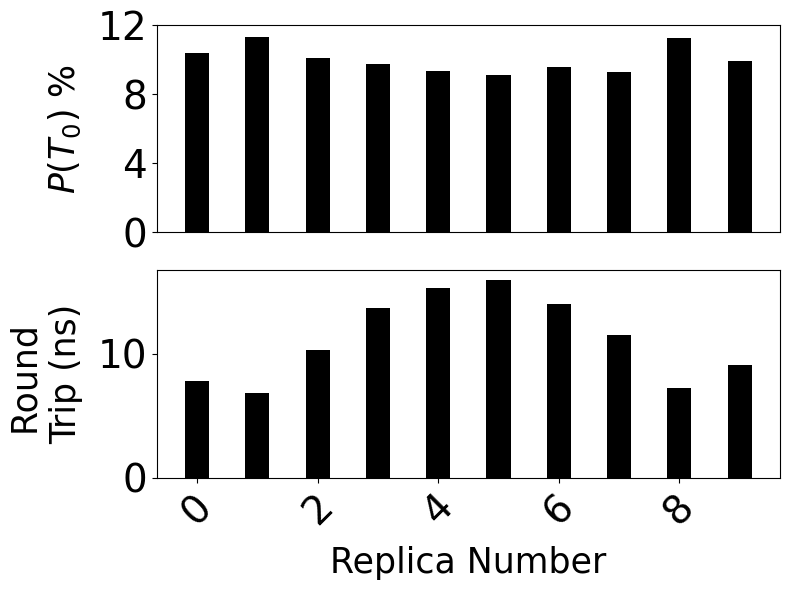

In [22]:
fig, ax = plt.subplots(2,1, figsize=(8,6), sharex=True)

ax[0].tick_params(axis='y', labelsize=28)
ax[0].bar(range(nrep[0]),prob_zero_rep.T[0],width = 0.4, color='k')
ax[0].set_yticks(np.arange(0,16,4),np.arange(0,16,4))
ax[0].set_ylabel(r'$P(T_{0})$ %', size=25, labelpad=10)


ax[0].tick_params(top=False, bottom=False,
                labeltop=False, labelbottom=False)

ax[1].tick_params(top=False, bottom=True,
                labeltop=False, labelbottom=True)
ax[1].tick_params(axis='x', labelsize=28)
ax[1].tick_params(axis='y', labelsize=28)
for keys in rt_dict.keys():
    ax[1].bar(keys,rt_dict[keys],width = 0.4, color='k')

ax[1].set_xticks(range(nrep[0])[::2],range(nrep[0])[::2], rotation=45)
# ax[1].set_yticks(range(0,1500,500),range(0,1500,500))
ax[1].set_ylabel(f"Round \nTrip (ns)", size=25, labelpad=10)
ax[1].set_xlabel('Replica Number', size=25, labelpad=10)

plt.tight_layout()

# Ignore this plot

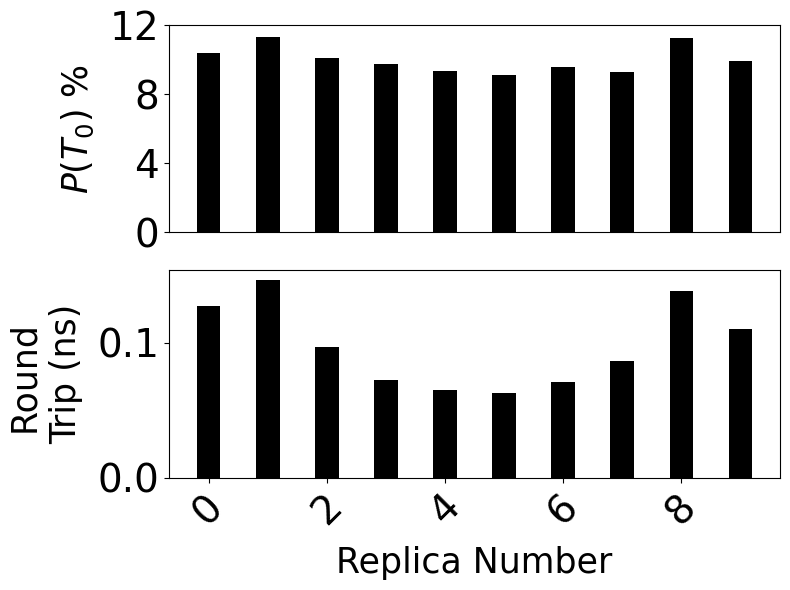

In [30]:
fig, ax = plt.subplots(2,1, figsize=(8,6), sharex=True)

ax[0].tick_params(axis='y', labelsize=28)
ax[0].bar(range(nrep[0]),prob_zero_rep.T[0],width = 0.4, color='k')
ax[0].set_yticks(np.arange(0,16,4),np.arange(0,16,4))
ax[0].set_ylabel(r'$P(T_{0})$ %', size=25, labelpad=10)


ax[0].tick_params(top=False, bottom=False,
                labeltop=False, labelbottom=False)

ax[1].tick_params(top=False, bottom=True,
                labeltop=False, labelbottom=True)
ax[1].tick_params(axis='x', labelsize=28)
ax[1].tick_params(axis='y', labelsize=28)
for keys in rt_dict.keys():
    ax[1].bar(keys,rt_dict[keys],width = 0.4, color='k')

ax[1].set_xticks(range(nrep[0])[::2],range(nrep[0])[::2], rotation=45)
# ax[1].set_yticks(range(0,1500,500),range(0,1500,500))
ax[1].set_ylabel(f"Round \nTrip (ns)", size=25, labelpad=10)
ax[1].set_xlabel('Replica Number', size=25, labelpad=10)

plt.tight_layout()